In [5]:
%%writefile transacoes.csv
id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario
2,2026-01-12,CLI002,debito,180.50,Supermercado,compra
3,2026-01-20,CLI001,debito,90.00,Farmácia,saude
4,2026-02-03,CLI004,debito,200.00,Transferência enviada,transferencia
5,2026-02-14,CLI003,credito,15000.00,Transferência suspeita,transferencia
6,2026-02-18,CLI002,debito,320.00,Conta de luz,conta
7,2026-03-01,CLI001,credito,3500.00,Salário março,salario
8,2026-03-10,CLI003,debito,99.90,Streaming,assinatura
9,2026-03-15,CLI005,credito,12000.00,Recebimento alto,transferencia
10,2026-04-02,CLI002,debito,450.00,Aluguel,conta
11,2026-04-07,CLI006,credito,2800.00,Freelance,servico
12,2026-04-15,CLI004,debito,75.50,Internet,conta
13,2026-05-01,CLI001,credito,3500.00,Salário maio,salario
14,2026-05-08,CLI005,debito,650.00,Compra online,compra
15,2026-05-20,CLI006,debito,120.00,Transporte,transporte
16,2026-01-30,CLI007,credito,900.00,Reembolso,reembolso
17,2026-02-28,CLI008,debito,85.00,Restaurante,alimentacao
18,2026-03-25,CLI009,credito,2200.00,Serviço extra,servico
,2026-04-01,CLI001,credito,100.00,ID vazio,teste
20,2026-04-10,,debito,200.00,Cliente vazio,teste
21,2026/04/15,CLI002,debito,300.00,Data inválida,teste
22,2026-05-05,CLI003,saque,500.00,Tipo inválido,teste
23,2026-05-10,CLI004,debito,abc,Valor inválido,teste

Writing transacoes.csv


In [6]:
import csv
import json
from datetime import datetime, date

LIMITE_SUSPEITO = 10000.00

In [7]:
def formatar_moeda(valor):
  return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [10]:
def ler_transacoes(caminho_arquivo):
  try:
    with open(caminho_arquivo, mode="r", encoding="utf-8") as arquivo:
      leitor = csv.DictReader(arquivo)
      return list(leitor)

  except FileNotFoundError:
      print(f"Erro: o arquivo {caminho_arquivo} não foi encontrado.")
      return []

In [11]:
def validar_transacao(linha):
    # valida id
    if not linha["id"] or not linha["id"].isdigit():
        return None

    # valida cliente
    if not linha["cliente_id"]:
        return None

    # valida tipo
    tipo = linha["tipo"].lower().strip()
    if tipo not in ["credito", "debito"]:
        return None

    # valida valor
    try:
        valor = float(linha["valor"])
        if valor <= 0:
            return None
    except ValueError:
        return None

    # valida data
    try:
        data_objeto = datetime.strptime(linha["data"], "%Y-%m-%d")
    except ValueError:
        return None

    transacao_limpa = {
        "id": int(linha["id"]),
        "data": data_objeto,
        "cliente_id": linha["cliente_id"],
        "tipo": tipo,
        "valor": valor,
        "descricao": linha["descricao"],
        "categoria": linha["categoria"],
        "suspeita": valor > LIMITE_SUSPEITO
    }

    return transacao_limpa

In [12]:
def gerar_relatorio(transacoes_validas, total_invalidas):
    resumo_mensal = {}
    transacoes_suspeitas = []

    datas = [transacao["data"] for transacao in transacoes_validas]

    data_mais_antiga = min(datas)
    data_mais_recente = max(datas)
    dias_periodo = (data_mais_recente - data_mais_antiga).days

    for transacao in transacoes_validas:
        mes = transacao["data"].strftime("%Y-%m")
        valor = transacao["valor"]

        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0,
                "total_debito": 0,
                "saldo": 0,
                "media": 0,
                "maior_valor": valor,
                "menor_valor": valor,
                "total_valor": 0
            }

        resumo_mensal[mes]["quantidade"] += 1
        resumo_mensal[mes]["total_valor"] += valor

        if transacao["tipo"] == "credito":
            resumo_mensal[mes]["total_credito"] += valor
        else:
            resumo_mensal[mes]["total_debito"] += valor

        if valor > resumo_mensal[mes]["maior_valor"]:
            resumo_mensal[mes]["maior_valor"] = valor

        if valor < resumo_mensal[mes]["menor_valor"]:
            resumo_mensal[mes]["menor_valor"] = valor

        if transacao["suspeita"]:
            transacoes_suspeitas.append({
                "id": transacao["id"],
                "cliente_id": transacao["cliente_id"],
                "data": transacao["data"].strftime("%Y-%m-%d"),
                "valor": transacao["valor"]
            })

    for mes, dados in resumo_mensal.items():
        dados["saldo"] = dados["total_credito"] - dados["total_debito"]
        dados["media"] = dados["total_valor"] / dados["quantidade"]
        del dados["total_valor"]

    relatorio = {
        "gerado_em": date.today().strftime("%Y-%m-%d"),
        "total_transacoes_validas": len(transacoes_validas),
        "total_transacoes_invalidas": total_invalidas,
        "periodo": {
            "data_mais_antiga": data_mais_antiga.strftime("%Y-%m-%d"),
            "data_mais_recente": data_mais_recente.strftime("%Y-%m-%d"),
            "dias_analisados": dias_periodo
        },
        "resumo_mensal": resumo_mensal,
        "transacoes_suspeitas": transacoes_suspeitas
    }

    return relatorio

In [13]:
def exibir_relatorio(relatorio):
    print("===== RELATÓRIO FINANCEIRO CLEARBANK =====")
    print()
    print(f"Gerado em: {relatorio['gerado_em']}")
    print(f"Período analisado: {relatorio['periodo']['data_mais_antiga']} → {relatorio['periodo']['data_mais_recente']}")
    print(f"Dias analisados: {relatorio['periodo']['dias_analisados']}")
    print(f"Total de transações válidas: {relatorio['total_transacoes_validas']}")
    print(f"Total de transações inválidas: {relatorio['total_transacoes_invalidas']}")
    print()

    print("===== RELATÓRIO MENSAL =====")
    print()

    for mes in sorted(relatorio["resumo_mensal"]):
        dados = relatorio["resumo_mensal"][mes]

        print(f"Mês: {mes}")
        print(f"  Transações:    {dados['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(dados['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(dados['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(dados['saldo'])}")
        print(f"  Média:         {formatar_moeda(dados['media'])}")
        print(f"  Maior valor:   {formatar_moeda(dados['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(dados['menor_valor'])}")
        print()

    print("===== TRANSAÇÕES SUSPEITAS =====")

    if relatorio["transacoes_suspeitas"]:
        for transacao in relatorio["transacoes_suspeitas"]:
            print(
                f"ID: {transacao['id']} | "
                f"Cliente: {transacao['cliente_id']} | "
                f"Data: {transacao['data']} | "
                f"Valor: {formatar_moeda(transacao['valor'])}"
            )
    else:
        print("Nenhuma transação suspeita encontrada.")

In [14]:
def salvar_json(relatorio, caminho_arquivo):
    with open(caminho_arquivo, mode="w", encoding="utf-8") as arquivo:
        json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)

In [15]:
transacoes_brutas = ler_transacoes("transacoes.csv")

transacoes_validas = []
transacoes_invalidas = 0

for linha in transacoes_brutas:
    transacao = validar_transacao(linha)

    if transacao is None:
        transacoes_invalidas += 1
    else:
        transacoes_validas.append(transacao)

print("===== RESUMO DA LIMPEZA =====")
print(f"Total de linhas lidas: {len(transacoes_brutas)}")
print(f"Linhas válidas: {len(transacoes_validas)}")
print(f"Linhas inválidas: {transacoes_invalidas}")
print()

relatorio = gerar_relatorio(transacoes_validas, transacoes_invalidas)

exibir_relatorio(relatorio)

salvar_json(relatorio, "relatorio.json")

print()
print("Arquivo relatorio.json gerado com sucesso!")

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 23
Linhas válidas: 18
Linhas inválidas: 5

===== RELATÓRIO FINANCEIRO CLEARBANK =====

Gerado em: 2026-06-15
Período analisado: 2026-01-05 → 2026-05-20
Dias analisados: 135
Total de transações válidas: 18
Total de transações inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:    4
  Total crédito: R$ 4.400,00
  Total débito:  R$ 270,50
  Saldo:         R$ 4.129,50
  Média:         R$ 1.167,62
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 90,00

Mês: 2026-02
  Transações:    4
  Total crédito: R$ 15.000,00
  Total débito:  R$ 605,00
  Saldo:         R$ 14.395,00
  Média:         R$ 3.901,25
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 85,00

Mês: 2026-03
  Transações:    4
  Total crédito: R$ 17.700,00
  Total débito:  R$ 99,90
  Saldo:         R$ 17.600,10
  Média:         R$ 4.449,98
  Maior valor:   R$ 12.000,00
  Menor valor:   R$ 99,90

Mês: 2026-04
  Transações:    3
  Total crédito: R$ 2.800,00
  Tota

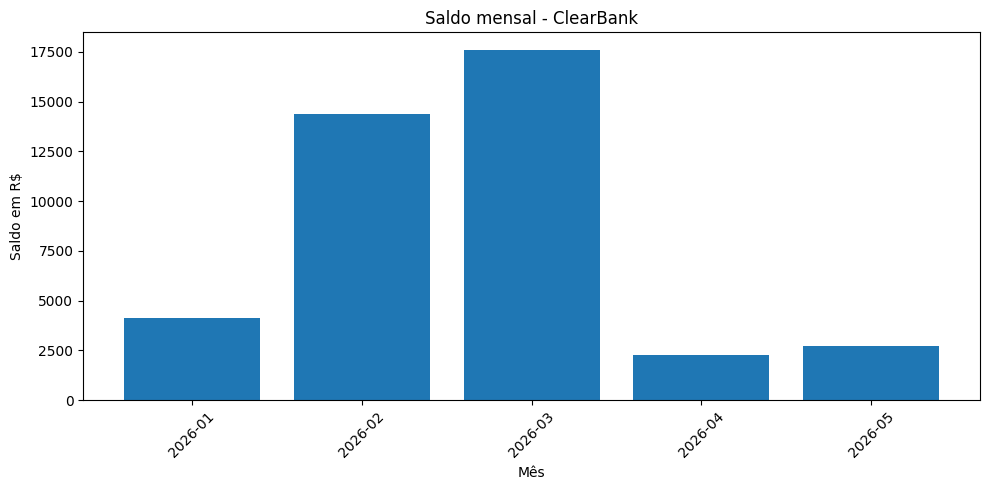

Arquivo grafico.png gerado com sucesso!


In [16]:
import matplotlib.pyplot as plt

meses = sorted(relatorio["resumo_mensal"].keys())
saldos = [relatorio["resumo_mensal"][mes]["saldo"] for mes in meses]

plt.figure(figsize=(10, 5))
plt.bar(meses, saldos)
plt.title("Saldo mensal - ClearBank")
plt.xlabel("Mês")
plt.ylabel("Saldo em R$")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("grafico.png")
plt.show()

print("Arquivo grafico.png gerado com sucesso!")

In [17]:
%%writefile README.md
# ClearBank Análise Financeira

Projeto desenvolvido em Python para leitura, validação e análise de transações bancárias a partir de um arquivo CSV.

## Objetivo

O notebook lê o arquivo `transacoes.csv`, valida os dados, remove registros inválidos, calcula métricas financeiras mensais, identifica transações suspeitas e exporta o resultado em JSON.

## Como executar

1. Abra o arquivo `desafio-final.ipynb` no Google Colab ou Jupyter Notebook.
2. Execute todas as células em ordem.
3. O notebook irá gerar o relatório no terminal e criar os arquivos de saída.

## Arquivo de entrada

- `transacoes.csv`

## Arquivos gerados

- `relatorio.json`: relatório final em formato JSON.
- `grafico.png`: gráfico com o saldo mensal.

## Funcionalidades

- Leitura de CSV com `csv.DictReader`
- Validação de dados
- Tratamento de erros com `try/except`
- Agrupamento mensal
- Cálculo de crédito, débito, saldo, média, maior e menor valor
- Identificação de transações suspeitas acima de R$ 10.000,00
- Exportação em JSON
- Geração de gráfico com matplotlib

Writing README.md
